# Production-Grade Data Engineering & ML Pipeline
## Retail Transaction Data — Customer Churn Prediction

---

### Business Context

A UK-based online retailer wants to proactively identify customers at risk of churning. By predicting churn before it happens, the business can deploy targeted retention campaigns, reducing customer acquisition costs and improving lifetime value.

### Problem Statement

Given historical transaction records at the invoice line-item level, we must:
1. Build a robust data pipeline that cleans, validates, and transforms raw data
2. Engineer meaningful customer-level features (RFM + behavioral)
3. Define a churn target without leaking future information
4. Train and evaluate an ML classifier using a production-grade sklearn Pipeline
5. Persist the full pipeline for deployment

### Dataset Description

| Column | Type | Description |
|--------|------|-------------|
| InvoiceNo | string | Unique invoice identifier |
| StockCode | string | Product code |
| Description | string | Product description |
| Quantity | int | Units purchased per line |
| InvoiceDate | datetime | Timestamp of invoice |
| UnitPrice | float | Price per unit (GBP) |
| CustomerID | float | Unique customer identifier |
| Country | string | Customer country |

**Granularity:** Each row is one *line item* within an invoice. Multiple rows share the same InvoiceNo. Multiple invoices belong to the same CustomerID.

**Why this matters:** You cannot directly model a line-item. The model operates at the *customer* level. We must aggregate upward — and every aggregation decision is a modeling decision.

### Notebook Roadmap

```
Section 1  → Title & Introduction (this section)
Section 2  → Environment Setup
Section 3  → Data Loading & Validation
Section 4  → Data Cleaning Pipeline
Section 5  → Advanced Pandas Analysis
Section 6  → Feature Engineering
Section 7  → Target Creation (Churn, Leakage-Free)
Section 8  → Time-Aware Train-Test Split
Section 9  → Machine Learning Pipeline
Section 10 → Model Persistence
Section 11 → Production Best Practices
Section 12 → Scaling Considerations
Section 13 → Final Summary
```

### 📌 Learning Objectives

By the end of this notebook, you will be able to:
- Think in **pipelines** — sequential, deterministic, composable transformations
- Think in **transformations** — pure functions with clear inputs and outputs
- Think about **leakage** — why random splits destroy time-series models
- Think about **reproducibility** — deterministic code with no hidden state
- Think about **scalability** — what happens when pandas fails

---

### Why Pipelines?

Raw transactional data is messy. It has:
- Missing customer IDs (anonymous sessions)
- Negative quantities (returns/cancellations)
- Zero or negative prices (data entry errors)
- Mixed granularity (line items vs invoices vs customers)

A *pipeline* forces you to express every cleaning and transformation step as an **explicit, ordered, reproducible function**. This means:
- New data flows through the same transformations automatically
- Bugs are isolated to a single function
- Your notebook is self-documenting
- Deployment is a matter of loading the pipeline object

### Why Customer-Level Aggregation?

Churn is a **customer-level** concept — a customer either churned or didn't. Line items have no concept of churn. We must collapse thousands of rows per customer into a single feature vector per customer. Every aggregation choice (sum vs mean vs max) encodes a business assumption. Document it.

---
# Section 2 — Environment Setup

We group imports by **category** so any reader immediately understands the tech stack. Installation is separated from imports so CI/CD systems can install dependencies independently of running the notebook.

In [43]:
# ============================================================
# CELL: Imports — grouped by category for clarity
# ============================================================

# --- Core Libraries ---
import pandas as pd
import numpy as np
import warnings
import logging
import sys
from datetime import datetime, timedelta
from pathlib import Path

# --- Visualization ---
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# --- Machine Learning ---
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix, roc_auc_score

# --- Pipeline & Preprocessing Tools ---
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import cross_val_score

# --- Persistence ---
import joblib

# ============================================================
# Display & Logging Configuration
# ============================================================

# Suppress low-priority warnings to keep output clean
warnings.filterwarnings('ignore')

# Basic logging: INFO level surfaces pipeline steps without overwhelming detail
logging.basicConfig(
    level = logging.INFO,
    format = '%(asctime)s | %(levelname)s | %(message)s',
    datefmt= '%H:%M:%S',
    force=True
)

logger = logging.getLogger(__name__)

# Pandas display: show more rows/columns so we see full structure
pd.set_option('display.max_columns', 20)
pd.set_option('display.max_rows', 60)
pd.set_option('display.float_format', '{:,.4f}'.format)
pd.set_option('display.width', 120)

# Matplotlib style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

# Reproducibility seed — fix this globally so all random operations are deterministic
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

logger.info('Environment Configured Sucessfully')
logger.info(f"Python, {sys.version}")
logger.info(f"Pandas, {pd.__version__} | Numpy {np.__version__}")



12:10:36 | INFO | Environment Configured Sucessfully
12:10:36 | INFO | Python, 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
12:10:36 | INFO | Pandas, 2.2.3 | Numpy 2.1.3


---
# Section 3 — Data Loading & Initial Validation

### Why validate before transforming?

The single most expensive debugging session is the one where you discover a data quality issue *after* running a 2-hour training job. Validation upfront costs minutes. Discovering schema drift in production costs days.

### Why inspect dtypes?

Pandas will silently infer `CustomerID` as `float64` (because of missing values) and `InvoiceDate` as `object`. If you don't inspect dtypes, you might apply numeric operations to strings or date operations to objects. The cost of not checking is silent, wrong results.

### Why check memory usage?

A 500k-row DataFrame of `object` columns can consume 10× more RAM than the equivalent optimized DataFrame. At 5M rows, this becomes an OOM crash. Knowing your memory footprint before transforming is essential for production sizing.

In [44]:
# ============================================================
# CELL: Load Data
# ============================================================

data = Path('retail_data.csv') # Adjust path as needed


# We specify encoding explicitly — retail CSVs often use latin-1 due to special characters
# in product descriptions (e.g., French accents, special symbols).

df_raw =pd.read_csv(
    data,
    encoding= 'latin-1',           # Handles special chars in Description field
    dtype={'CustomerID' : str},  # Load as str first; we control the type later
    low_memory=False                # Prevent mixed-type inference warnings on large files

)

In [45]:
# ============================================================
# CELL: Dtype Inspection
# Expected: InvoiceDate as object (string) — we'll parse it.
# CustomerID as object — intentional; we'll handle NaN and convert.
# ============================================================


print('=== Data Types ===')
print(df_raw.dtypes)

print('\n=== Data Info ===')
df_raw.info(memory_usage='deep')

=== Data Types ===
InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID      object
Country         object
dtype: object

=== Data Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46431 entries, 0 to 46430
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   InvoiceNo    46431 non-null  object 
 1   StockCode    46431 non-null  object 
 2   Description  46431 non-null  object 
 3   Quantity     46431 non-null  int64  
 4   InvoiceDate  46431 non-null  object 
 5   UnitPrice    46431 non-null  float64
 6   CustomerID   44951 non-null  object 
 7   Country      46431 non-null  object 
dtypes: float64(1), int64(1), object(6)
memory usage: 16.5 MB


In [46]:
# ============================================================
# CELL: Missing Value Analysis
# We want to know: which columns are missing, how much, and why.
# CustomerID NaN = anonymous/guest checkout. These rows cannot be
# attributed to a specific customer and must be dropped for
# customer-level modeling.
# Description NaN = a data entry issue; we can drop or flag.
# ============================================================


missing = pd.DataFrame({
    'missing_count': df_raw.isnull().sum(),
    'missing_pct' : (df_raw.isnull().sum()/ len(df_raw) * 100).round(2)
}).sort_values('missing_pct', ascending= False)

print('=== MISSING VALUES ===')
print(missing[missing.missing_count > 0])

=== MISSING VALUES ===
            missing_count  missing_pct
CustomerID           1480       3.1900


In [47]:
# ============================================================
# CELL: Duplicate Detection
# Full duplicates (every column identical) are likely ETL errors.
# Invoice+StockCode duplicates may be legitimate if re-submitted,
# but worth flagging.
# ============================================================

full_dupes = df_raw.duplicated().sum()
invoice_dupes = df_raw.duplicated(subset=['InvoiceNo', 'StockCode']).sum()

print(f'Full Duplicated Rows:  {full_dupes:,}')
print(f'InvoiceNo + StockCode Duplcates:  {invoice_dupes:,}')

Full Duplicated Rows:  90
InvoiceNo + StockCode Duplcates:  213


In [48]:
# ============================================================
# CELL: Memory Usage — Baseline
# We'll compare this to the optimized version in Section 5.
# ============================================================

mem_mb_raw = df_raw.memory_usage(deep=True).sum() / 1024**2
print(f'Raw DataFrame memory usage: {mem_mb_raw:.2f} MB\n')

col_mem = (df_raw.memory_usage(deep= True) / (1024**2)).sort_values(ascending=False)
print(col_mem.to_string())

Raw DataFrame memory usage: 16.54 MB

Description   3.3245
InvoiceDate   2.8504
Country       2.4673
InvoiceNo     2.4368
StockCode     2.3923
CustomerID    2.3601
Quantity      0.3542
UnitPrice     0.3542
Index         0.0001


In [49]:
# ============================================================
# CELL: Basic Statistics — Sanity check numeric columns
# Look for: negative Quantity (returns), zero/negative UnitPrice,
# extreme outliers in any column.
# ============================================================
print("=== DESCRIPTIVE STATISTICS ===\n")
display(df_raw[['Quantity', 'UnitPrice']].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]))

# Flag suspicious rows before cleaning

n_neg_quantity = (df_raw['Quantity'] < 0).sum()
n_zero_quantity = (df_raw['UnitPrice'] <= 0).sum()
n_cancel = df_raw['InvoiceNo'].astype(str).str.startswith('C').sum()
print(f'Negative quantity is: {n_neg_quantity}, Zero quantity is: {n_zero_quantity}, Cancelled order is: {n_cancel}.')


=== DESCRIPTIVE STATISTICS ===



,Quantity,UnitPrice
count,"46,431.0000","46,431.0000"
mean,19.6554,5.4509
std,47.2337,63.3605
min,-624.0000,0.0000
1%,-6.0000,0.2900
5%,1.0000,0.4200
25%,4.0000,1.2500
50%,10.0000,1.9500
75%,16.0000,3.7500
95%,80.0000,12.7500


Negative quantity is: 1432, Zero quantity is: 18, Cancelled order is: 1432.


---
# Section 4 — Data Cleaning Pipeline

### Philosophy: Modular, Deterministic, Pure Functions

**Modular:** Each cleaning step is its own function. If step 3 has a bug, you fix exactly one function — not hunt through 200 lines of notebook code.

**Deterministic:** Given the same input, the function always produces the same output. No random sampling, no global state, no side effects on the input DataFrame.

**Pure functions:** Each function receives a DataFrame and returns a *new* DataFrame. We never mutate `df_raw`. This is crucial for debugging — you can re-run any step in isolation.

### The Master Pipeline Pattern

A `run_pipeline()` function composes individual steps. This mirrors what sklearn Pipelines do internally. The advantage: when you need to add a new cleaning step, you add one function and one line in `run_pipeline()`. Everything else stays the same.

### Why we do NOT write everything in one block

A single 100-line cleaning block is:
- Untestable (you can't unit test a block)
- Unreadable (you can't explain what line 73 does)
- Fragile (changing line 30 can silently break line 80)

In [50]:
def drop_missing_customer_id(df: pd.DataFrame) -> pd.DataFrame:

    """
      Remove rows where CustomerID is null.

      Rationale:
          Null CustomerID indicates a guest/anonymous checkout. These
          cannot be linked to a customer history and are therefore
          useless for customer-level churn modeling.

      Args:
          df: Raw input DataFrame.

      Returns:
          DataFrame with anonymous rows removed.
      """
    before = len(df)
    df_clean = df.dropna(subset=['CustomerID']).copy()
    after = len(df_clean)
    logger.info(f'[drop_missing_customer_id] Removed {before - after:,} rows | Remaining: {after:,}')
    return df_clean


In [51]:
# ============================================================
# CELL: Step 2 — Remove negative quantities and cancellations
# Negative quantities are returns. Invoices starting with 'C'
# are cancellations. Both distort revenue-based features.
# NOTE: In a revenue *analysis* notebook you'd handle returns
# differently. For churn *modeling*, we focus on actual purchases.
# ============================================================


def remove_invalid_transaction(df: pd.DataFrame) -> pd.DataFrame:
    """
      Remove returns, cancellations, and zero-price rows.

      Rationale:
          - Negative Quantity → product return, not a purchase signal
          - InvoiceNo starting with 'C' → cancellation invoice
          - UnitPrice <= 0 → likely a data entry error or internal transfer

      Args:
          df: DataFrame after CustomerID cleaning.

      Returns:
          DataFrame with only valid purchase transactions.
      """

    before = len(df)

    # Filter positive quantities only (true purchases)
    df_clean = df[df['Quantity'] > 0].copy()

    # Remove cancellation invoices
    df_clean = df_clean[~df_clean['InvoiceNo'].astype(str).str.startswith('C')]

    # Remove zero or negative prices
    df_clean = df_clean[df_clean['UnitPrice'] > 0]

    after = len(df)
    logger.info(f'[remove_invalid_transaction] Removed {before- after:,} rows | Remaining {after:,} ')
    return df_clean



In [52]:
# ============================================================
# CELL: Step 3 — Parse InvoiceDate to datetime
# Pandas reads dates as strings. We must parse them explicitly.
# Specifying the format string is faster and more reliable than
# letting pandas infer (which can silently misparse ambiguous dates
# like 01/02/2010 — is that Jan 2 or Feb 1?).
# ============================================================

def parse_invoice_data(df: pd.DataFrame) -> pd.DataFrame:

    """
      Parse InvoiceDate string column into pandas datetime.

      Rationale:
          Time-based features (recency, month, day-of-week) require
          proper datetime objects. String dates cannot be compared,
          differenced, or aggregated by time period.

          This function:
          - Standardizes separators
          - Parses with deterministic logic
          - Fails loudly on invalid values

      Args:
          df: DataFrame with InvoiceDate as string.

      Returns:
          DataFrame with InvoiceDate as datetime64.
      """

    df = df.copy()

    # Step 1: Standardize separators (avoid mixed '/' and '-')
    df['InvoiceDate'] = (
        df['InvoiceDate']
        .astype(str)
        .str.strip()
        .str.replace('/', '-', regex= False)
    )

    # Step 2: Parse using explicit format
    df['InvoiceDate'] = pd.to_datetime(
        df['InvoiceDate'],
        format = '%d-%m-%Y %H:%M',
        errors = 'raise' #Fail loudly for production safety
    )

    logger.info(
        f"[parse_invoice_data] Date Range: "
        f"{df['InvoiceDate'].min()} {df['InvoiceDate'].max()}"
    )

    return df


In [53]:
# ============================================================
# CELL: Step 4 — Create Revenue column
# Revenue = Quantity × UnitPrice
# This is a derived column — computed once during cleaning and
# used in multiple downstream aggregations.
# ============================================================

def create_revenue_column(df: pd.DataFrame) -> pd.DataFrame:
    """
      Compute per-line-item revenue.

      Rationale:
          Revenue is the fundamental monetary metric. Rather than
          recomputing Quantity * UnitPrice at every aggregation point,
          we create it once here. Single source of truth.

      Args:
          df: Cleaned DataFrame with Quantity and UnitPrice.

      Returns:
          DataFrame with new 'Revenue' column.
      """

    df= df.copy()

    df['Revenue'] = df['Quantity'] * df['UnitPrice']
    logger.info(f'[create_revenu_column] Total  Revenue: {df['Revenue'].sum():,.2f}')

    return df


In [54]:
# ============================================================
# CELL: Step 5 — Standardize CustomerID type
# After dropping NaNs, CustomerID can be safely cast to string
# (removing decimal notation like '12345.0').
# ============================================================

def clean_customer_id(df: pd.DataFrame) -> pd.DataFrame:
      """
      Standardize CustomerID format.

      Rationale:
          CustomerIDs read as '12345.0' due to float inference during
          CSV loading. We strip the decimal suffix for clean joins
          and groupby operations.

      Args:
          df: DataFrame post CustomerID null removal.

      Returns:
          DataFrame with CustomerID as clean integer string.
      """

      df = df.copy()

      # Convert to float first (handles '12345.0'), then int, then str
      df['CustomerID'] = df['CustomerID'].astype(float).astype(int).astype(str)
      logger.info(f'[clean_customer_id] Unique Customers: {df['CustomerID'].nunique():,}')
      return df



In [55]:
# ============================================================
# CELL: Master Pipeline — run_pipeline()
# This function is the single entry point for cleaning.
# Order matters: we must drop CustomerID nulls BEFORE
# clean_customer_id() tries to cast them.
# ============================================================

def run_pipeline(df: pd.DataFrame) -> pd.DataFrame:
    """
    Master data cleaning pipeline.

    Composes all cleaning steps in the correct order. Each step
    receives the output of the previous step — exactly like
    sklearn's Pipeline object.

    Pipeline order:
        1. drop_missing_customer_id   → ensures clean IDs before casting
        2. remove_invalid_transactions → removes noise before feature calc
        3. parse_invoice_date         → enables time-based operations
        4. create_revenue_column      → requires clean Quantity & UnitPrice
        5. clean_customer_id          → final ID standardization

    Args:
        df: Raw input DataFrame.

    Returns:
        Cleaned DataFrame ready for feature engineering.
    """

    logger.info("Start Cleaning Pipeline")

    df = drop_missing_customer_id(df)
    df = remove_invalid_transaction(df)
    df = parse_invoice_data(df)
    df = create_revenue_column(df)
    df = clean_customer_id(df)

    logger.info(f"Pipeline complete. Final shape: {df.shape}")
    return df

df = run_pipeline(df_raw)
display(df.head(5))


12:10:36 | INFO | Start Cleaning Pipeline
12:10:36 | INFO | [drop_missing_customer_id] Removed 1,480 rows | Remaining: 44,951
12:10:37 | INFO | [remove_invalid_transaction] Removed 0 rows | Remaining 44,951 
12:10:37 | INFO | [parse_invoice_data] Date Range: 2010-12-01 08:45:00 2011-12-09 12:50:00
12:10:37 | INFO | [create_revenu_column] Total  Revenue: 1,603,016.35
12:10:37 | INFO | [clean_customer_id] Unique Customers: 418
12:10:37 | INFO | Pipeline complete. Final shape: (43563, 9)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536370,22728,ALARM CLOCK BAKELIKE PINK,24,2010-12-01 08:45:00,3.7500,12583,France,90.0000
1,536370,22727,ALARM CLOCK BAKELIKE RED,24,2010-12-01 08:45:00,3.7500,12583,France,90.0000
2,536370,22726,ALARM CLOCK BAKELIKE GREEN,12,2010-12-01 08:45:00,3.7500,12583,France,45.0000
3,536370,21724,PANDA AND BUNNIES STICKER SHEET,12,2010-12-01 08:45:00,0.8500,12583,France,10.2000
4,536370,21883,STARS GIFT TAPE,24,2010-12-01 08:45:00,0.6500,12583,France,15.6000


---
# Section 5 — Advanced Pandas Analysis

This section demonstrates professional-grade pandas patterns:
- Multi-level GroupBy aggregation
- Pivot tables for cross-tabulation
- Window functions for rolling/cumulative metrics
- Memory optimization techniques

These are not just analytical tools — they are the building blocks of feature engineering.

## 5.1 — GroupBy Multi-Level Aggregation

GroupBy is the workhorse of pandas analytics. The key skill is knowing *what to aggregate* and *which aggregation function encodes the right business assumption*.

- `sum` → total monetary value
- `count` / `nunique` → frequency / distinct events
- `mean` → average behavior
- `max` / `min` → extreme events (last purchase, largest order)

In [56]:
# ============================================================
# Revenue per Customer — the fundamental business metric
# nunique(InvoiceNo) = number of distinct purchase occasions
# sum(Revenue) = total customer lifetime value contribution
# ============================================================

revenue_per_customer = (
    df.groupby('CustomerID')
    .agg(
        total_revenue = ('Revenue','sum'),
        n_invoices = ('InvoiceNo','nunique'),
        n_items = ('Quantity','sum'),
        average_order_mean = ('Revenue','mean'),
        first_purchase = ('InvoiceDate', 'min'),
        last_purchase = ('InvoiceDate', 'max')
    )
    .reset_index()
    .sort_values("total_revenue", ascending=False)
)

print(f"Customer level aggregation shape: {revenue_per_customer.shape}")
display(revenue_per_customer.head(10))

Customer level aggregation shape: (418, 7)


,CustomerID,total_revenue,n_invoices,n_items,average_order_mean,first_purchase,last_purchase
394,14646,"280,206.0200",73,196915,134.9740,2010-12-20 10:09:00,2011-12-08 12:12:00
395,14911,"143,825.0600",201,80265,25.3436,2010-12-01 14:05:00,2011-12-08 15:54:00
54,12415,"124,914.5300",21,77374,174.9503,2011-01-06 11:12:00,2011-11-15 14:22:00
387,14156,"117,379.6300",55,57885,83.8426,2010-12-03 11:48:00,2011-11-30 10:54:00
411,17404,"31,906.8200",15,32748,161.1456,2010-12-14 13:28:00,2011-12-05 16:26:00
326,12753,"21,429.3900",6,11421,108.7786,2010-12-12 11:44:00,2011-11-17 10:52:00
323,12744,"21,279.2900",7,5241,95.8527,2011-01-25 13:26:00,2011-10-19 11:18:00
99,12471,"19,824.0500",30,8212,43.0958,2010-12-10 09:35:00,2011-12-07 15:43:00
313,12731,"18,895.9100",12,8437,68.9632,2010-12-10 10:56:00,2011-11-16 11:59:00
268,12678,"17,628.4600",12,10923,106.8392,2010-12-21 11:00:00,2011-10-28 13:04:00


In [57]:
# ============================================================
# Revenue per Country — geographic business insight
# This shows where revenue is concentrated and informs
# whether Country is a useful modeling feature.
# ============================================================

revenue_per_country = (
    df.groupby("Country")
    .agg(
        total_revenue = ('Revenue', 'sum'),
        n_customers = ('CustomerID','nunique'),
        n_transaction = ('InvoiceNo','nunique'),
        avg_order_value = ('Revenue', 'mean')
    )
    .reset_index()
    .sort_values('total_revenue', ascending=False)
)

print(f"Top 10 Countries by Revenue")
display(revenue_per_country.head(10))

Top 10 Countries by Revenue


,Country,total_revenue,n_customers,n_transaction,avg_order_value
23,Netherlands,"285,446.3400",9,94,121.0031
10,EIRE,"265,545.9000",3,260,36.6979
14,Germany,"228,867.1400",94,457,25.3172
13,France,"209,024.0500",87,389,25.0598
0,Australia,"138,521.3100",9,57,117.1923
30,Spain,"61,577.1100",30,90,24.7895
32,Switzerland,"56,443.9500",21,51,30.6594
3,Belgium,"41,196.3400",25,98,20.2838
31,Sweden,"38,378.3300",8,36,85.0961
19,Japan,"37,416.3700",8,19,116.5619


,YearMonth,total_revenue,n_customer,n_transaction
0,2010-12,"74,052.0400",70,109
1,2011-01,"127,254.9800",94,113
2,2011-02,"91,481.7200",79,101
3,2011-03,"128,302.1700",94,144
4,2011-04,"59,641.2200",72,91
5,2011-05,"127,025.7400",94,152
6,2011-06,"136,298.2100",102,144
7,2011-07,"114,478.7600",90,131
8,2011-08,"146,890.5800",101,147
9,2011-09,"156,058.1100",120,187


12:10:37 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
12:10:37 | INFO | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


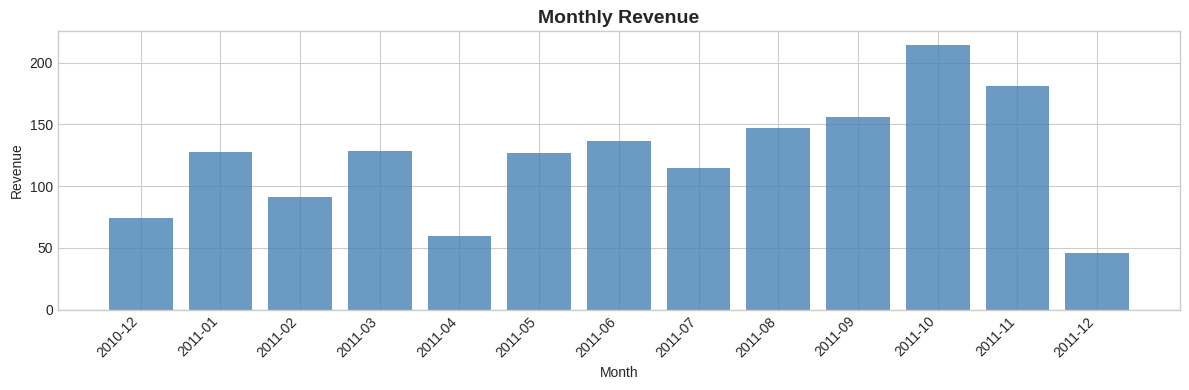

In [58]:
# ============================================================
# Revenue per Month — temporal business insight
# We create a YearMonth period column for clean monthly grouping.
# This avoids 'Dec 2010' and 'Dec 2011' collapsing into the same group.
# ============================================================

df['YearMonth'] = df['InvoiceDate'].dt.to_period('M')

revenue_per_month = (
    df.groupby('YearMonth')
    .agg(
        total_revenue = ('Revenue', 'sum'),
        n_customer  = ('CustomerID', 'nunique'),
        n_transaction = ('InvoiceNo', 'nunique'),
    )
    .reset_index()
    .sort_values('YearMonth')
)

display(revenue_per_month)

# Visualize monthly revenue trend
fig, ax = plt.subplots(figsize=(12,4))
ax.bar(
    revenue_per_month['YearMonth'].astype(str),
    revenue_per_month['total_revenue'] / 1000,
    color= 'steelblue', alpha= 0.8
)

ax.set_title('Monthly Revenue', fontsize=14, fontweight= 'bold')
ax.set_xlabel('Month')
ax.set_ylabel('Revenue')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Pivot Tables

Pivot tables rotate GroupBy results into a matrix format — rows represent one dimension, columns another. They are powerful for spotting patterns that are invisible in long-format tables.

In [59]:
# ============================================================
# Country × Month Revenue Pivot
# Shows which countries drive revenue in which months.
# Useful for detecting seasonal patterns or country-specific campaigns.
# filter to top 5 countries by total revenue for readability.
# ============================================================

top_5_countries = revenue_per_country.head(5)['Country'].tolist()

pivot_country_month = pd.pivot_table(
    df[df['Country'].isin(top_5_countries)],
    values = 'Revenue',
    index = 'Country',
    columns = 'YearMonth',
    aggfunc = 'sum',
    fill_value=0   # Countries with no sales in a month get 0, not NaN
)

print("Country × Month Revenue Pivot (£):")
display(pivot_country_month.style.format('{:,.0f}').background_gradient(cmap='Blues', axis=1))

Country × Month Revenue Pivot (£):


YearMonth,2010-12,2011-01,2011-02,2011-03,2011-04,2011-05,2011-06,2011-07,2011-08,2011-09,2011-10,2011-11,2011-12
Country,,,,,,,,,,,,,
Australia,"1,033","9,018","14,695","17,224",772,"13,638","25,188","4,964","22,489","5,107","17,151","7,243",0
EIRE,"8,814","21,904","10,127","21,674","7,570","15,982","19,836","40,905","16,967","40,995","24,318","29,473","6,979"
France,"9,616","17,740","8,516","14,590","5,530","17,615","16,079","10,000","13,811","23,428","33,485","31,337","7,277"
Germany,"15,241","16,911","9,581","14,393","12,316","25,751","13,274","16,441","19,221","18,091","31,638","28,025","7,984"
Netherlands,"8,784","26,611","23,012","22,416","2,977","29,186","26,858",26,"40,328","26,937","40,709","25,874","11,728"


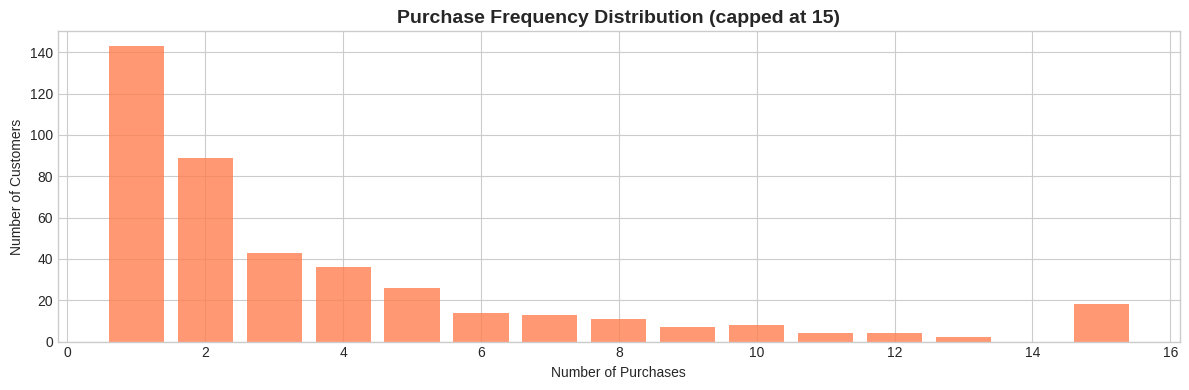


Insight: Most customers purchase only once (high one-time buyer rate).
This is a common pattern in e-commerce and drives the churn problem.


In [60]:
# ============================================================
# Customer Purchase Frequency Pivot
# How many customers make exactly 1 purchase? 2? 10+?
# This shapes the churn definition — a customer with 1 purchase
# is not churned, they may just be new.
# ============================================================

freq_dist = (
    revenue_per_customer['n_invoices']
    .clip(upper=15)  # Group customers with 15+ orders into one bucket
    .value_counts()
    .sort_index()
    .reset_index()
)
freq_dist.columns = ['n_purchases', 'n_customers']

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(freq_dist['n_purchases'], freq_dist['n_customers'], color='coral', alpha=0.8)
ax.set_title('Purchase Frequency Distribution (capped at 15)', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Purchases')
ax.set_ylabel('Number of Customers')
plt.tight_layout()
plt.show()

print("\nInsight: Most customers purchase only once (high one-time buyer rate).")
print("This is a common pattern in e-commerce and drives the churn problem.")

##  Window Functions

Window functions compute values across a *sliding window* of rows. Unlike GroupBy, they **do not collapse rows** — each row gets its own window-computed value. This is critical for time-series pattern detection.

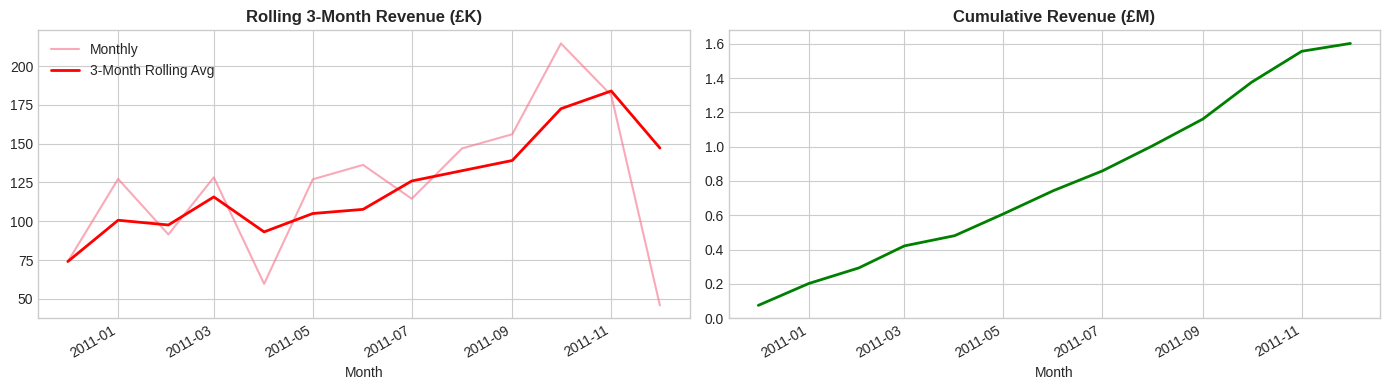

In [ ]:
# ============================================================
# Rolling and Cumulative Revenue by Month
# Rolling 3-month revenue: smooths out seasonal spikes
# Cumulative revenue: tracks total business growth over time
# ============================================================

monthly_revenue = revenue_per_month.copy()
monthly_revenue['YearMonth_dt'] = monthly_revenue['YearMonth'].dt.to_timestamp()
monthly_revenue = monthly_revenue.sort_values('YearMonth_dt')

# Rolling 3-month sum: shows short-term momentum
monthly_revenue['rolling_3m_revenue'] = (
    monthly_revenue['total_revenue']
    .rolling(window=3, min_periods=1)  # min_periods=1 avoids NaN at the start
    .mean()
)

# Cumulative revenue: overall business trajectory
monthly_revenue['cumulative_revenue'] = monthly_revenue['total_revenue'].cumsum()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(monthly_revenue['YearMonth_dt'], monthly_revenue['total_revenue'] / 1000,
             label='Monthly', alpha=0.6)
axes[0].plot(monthly_revenue['YearMonth_dt'], monthly_revenue['rolling_3m_revenue'] / 1000,
             label='3-Month Rolling Avg', linewidth=2, color='red')
axes[0].set_title('Rolling 3-Month Revenue (£K)', fontweight='bold')
axes[0].legend()

axes[1].plot(monthly_revenue['YearMonth_dt'], monthly_revenue['cumulative_revenue'] / 1e6,
             color='green', linewidth=2)
axes[1].set_title('Cumulative Revenue (£M)', fontweight='bold')

for ax in axes:
    ax.set_xlabel('Month')
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# Customer Revenue Ranking
# Rank customers by total revenue using percent_rank.
# Useful for identifying top decile (VIP) vs bottom decile
# customers — both are targets for different campaigns.
# ============================================================

revenue_per_customer['revenue_rank'] = (
    revenue_per_customer['total_revenue']
    .rank(method='dense', ascending=False)
    .astype(int)
)

revenue_per_customer['revenue_percentile'] = (
    revenue_per_customer['total_revenue']
    .rank(pct=True)
    .round(4)
)

print("Top 10 Customers by Revenue:")
display(revenue_per_customer[['CustomerID', 'total_revenue', 'n_invoices', 'revenue_rank', 'revenue_percentile']].head(10))

print("\nInsight: The top 10% of customers typically drive 50-60% of revenue.")
top_10pct = revenue_per_customer[revenue_per_customer['revenue_percentile'] >= 0.9]
total_rev = revenue_per_customer['total_revenue'].sum()
top_10_share = top_10pct['total_revenue'].sum() / total_rev * 100
print(f"Top 10% of customers account for {top_10_share:.1f}% of total revenue.")

Top 10 Customers by Revenue:


,CustomerID,total_revenue,n_invoices,revenue_rank,revenue_percentile
394,14646,"280,206.0200",73,1,1.0000
395,14911,"143,825.0600",201,2,0.9976
54,12415,"124,914.5300",21,3,0.9952
387,14156,"117,379.6300",55,4,0.9928
411,17404,"31,906.8200",15,5,0.9904
326,12753,"21,429.3900",6,6,0.9880
323,12744,"21,279.2900",7,7,0.9856
99,12471,"19,824.0500",30,8,0.9833
313,12731,"18,895.9100",12,9,0.9809
268,12678,"17,628.4600",12,10,0.9785



Insight: The top 10% of customers typically drive 50-60% of revenue.
Top 10% of customers account for 67.6% of total revenue.


## Memory Optimization

### Why does memory matter in production?

A production data pipeline may run on a cloud instance with limited RAM. Pandas loads data entirely into memory. If your DataFrame uses 8GB on a 16GB machine, there's no room to create copies during transformations — and pandas *always* creates copies during most operations.

**Key optimizations:**
- `category` dtype for low-cardinality string columns (Country, StockCode)
- Downcast `float64` → `float32` for columns that don't need double precision
- Downcast `int64` → `int32` or `int16` where value range allows

In [ ]:
# ============================================================
# Memory Optimization — Before & After
# ============================================================

mem_before = df.memory_usage(deep=True).sum() / (1024**2)
print(f"Memory BEFORE optimization: {mem_before:.2f} MB")

df_optimized = df.copy()

# Country: low cardinality (few unique values, many rows) → category saves huge memory
# Object stores full string bytes per cell; category stores integer codes + a lookup table
n_country_unique = df_optimized['Country'].nunique()
n_country_total  = len(df_optimized)
print(f"Country: {n_country_unique} unique values across {n_country_total:,} rows → ideal for category")
df_optimized['Country'] = df_optimized['Country'].astype('category')

# Similarly for StockCode
df_optimized['StockCode'] = df_optimized['StockCode'].astype('category')

# Downcast numerics — Quantity rarely exceeds int32 range (±2.1B)
df_optimized['Quantity'] = pd.to_numeric(df_optimized['Quantity'], downcast='integer')

# UnitPrice doesn't need float64 precision
df_optimized['UnitPrice'] = df_optimized['UnitPrice'].astype('float32')
df_optimized['Revenue']   = df_optimized['Revenue'].astype('float32')

mem_after = df_optimized.memory_usage(deep=True).sum() / (1024**2)
reduction = (1 - mem_after / mem_before) * 100

print(f"\nMemory AFTER optimization:  {mem_after:.2f} MB")
print(f"Memory reduction: {reduction:.1f}%")

# Update working DataFrame
df = df_optimized

Memory BEFORE optimization: 14.20 MB
Country: 36 unique values across 43,563 rows → ideal for category

Memory AFTER optimization:  9.39 MB
Memory reduction: 33.9%


---
# Section 6 — Feature Engineering

Feature engineering is the art of converting raw transactional data into a single row per customer that captures *who that customer is* as a buyer.

### RFM Framework

RFM (Recency, Frequency, Monetary) is the industry-standard framework for customer behavioral modeling. It was developed in direct marketing in the 1980s and remains highly predictive because it captures three orthogonal dimensions of customer behavior:

- **Recency**: How recently did the customer purchase? A customer who bought yesterday is unlikely to have churned.
- **Frequency**: How often do they purchase? High-frequency customers have stronger engagement signals.
- **Monetary**: How much do they spend? High-value customers warrant different retention strategies.

### Feature Dictionary

| Feature | Type | Definition | Business Meaning |
|---------|------|------------|------------------|
| recency_days | numeric | Days since last purchase (from reference date) | Lower = more recent = lower churn risk |
| frequency | numeric | Number of distinct invoices | Higher = more engaged customer |
| monetary | numeric | Total revenue (£) | Higher = more valuable customer |
| avg_basket_value | numeric | monetary / frequency | Spend per trip |
| tenure_days | numeric | Days from first to last purchase | Longer = more established relationship |
| purchase_interval | numeric | tenure / (frequency - 1) | Avg days between purchases |
| unique_products | numeric | Distinct StockCodes purchased | Breadth of product engagement |
| unique_countries | numeric | Distinct Countries in orders | Shipping complexity |
| year | numeric | Year of first purchase | Cohort indicator |
| month_first | numeric | Month of first purchase | Seasonality of acquisition |
| dow_mode | numeric | Most frequent day-of-week for purchases | Shopping behavior pattern |
| dominant_country | categorical | Most frequent country in orders | Geographic segment |

In [ ]:
# ============================================================
# Reference Date for Recency
#
# CRITICAL DECISION: What is the reference date?
# Option A: Today's date → recency changes every time you run the notebook
# Option B: max(InvoiceDate) + 1 day → deterministic, reproducible
#
# We choose Option B. This makes the notebook deterministic:
# same data → same features → same model → reproducible results.
# ============================================================

REFERENCE_DATE = df['InvoiceDate'].max() + timedelta(days=1)
print(f"Reference date for recency calculation: {REFERENCE_DATE.date()}")
print("(This is 1 day after the last transaction in the dataset — fully deterministic)")

Reference date for recency calculation: 2011-12-10
(This is 1 day after the last transaction in the dataset — fully deterministic)


In [ ]:
# ============================================================
# CELL: Build Customer Feature Table
# All aggregations in one groupby for efficiency.
# Multiple trips through the data (one groupby per feature)
# is slower and harder to read.
# ============================================================

def build_customer_features(df: pd.DataFrame, reference_date: pd.Timestamp) -> pd.DataFrame:
    """
    Aggregate transaction-level data into one row per customer.

    This is the core feature engineering step. Every feature here
    is computed using only data from BEFORE the reference date.
    The reference date acts as a 'current date' boundary.

    Args:
        df: Cleaned transaction DataFrame.
        reference_date: The date used as 'today' for recency.

    Returns:
        Customer-level feature DataFrame (one row per CustomerID).
    """

    # --- Core RFM Aggregation ---
    rfm = df.groupby('CustomerID').agg(
        # Recency: days since most recent purchase
        last_purchase_date = ('InvoiceDate', 'max'),
        first_purchase_date= ('InvoiceDate', 'min'),

        # Frequency: distinct purchase occasions (not line items)
        frequency          = ('InvoiceNo', 'nunique'),

        # Monetary: total spend
        monetary           = ('Revenue', 'sum'),

        # Breadth of engagement
        unique_products    = ('StockCode', 'nunique'),
        total_items        = ('Quantity', 'sum'),

        # Geographic: dominant market
        dominant_country   = ('Country', lambda x: x.mode()[0]),
        n_countries        = ('Country', 'nunique'),
    ).reset_index()

    # --- Derived Features ---
    # Recency in days (integer)
    rfm['recency_days'] = (
        (reference_date - rfm['last_purchase_date']).dt.days
    )

    # Customer tenure: span of purchase history
    rfm['tenure_days'] = (
        (rfm['last_purchase_date'] - rfm['first_purchase_date']).dt.days
    )

    # Average basket value: spend per trip
    rfm['avg_basket_value'] = rfm['monetary'] / rfm['frequency']

    # Average items per invoice
    rfm['avg_items_per_invoice'] = rfm['total_items'] / rfm['frequency']

    # Purchase interval: average days between purchases
    # Only meaningful for customers with > 1 purchase
    rfm['purchase_interval'] = np.where(
        rfm['frequency'] > 1,
        rfm['tenure_days'] / (rfm['frequency'] - 1),
        np.nan  # Undefined for single-purchase customers
    )

    # --- Time-Based Features (from first purchase) ---
    rfm['year_first_purchase']  = rfm['first_purchase_date'].dt.year
    rfm['month_first_purchase'] = rfm['first_purchase_date'].dt.month
    rfm['quarter_first_purchase'] = rfm['first_purchase_date'].dt.quarter

    # Drop intermediate date columns — they are not model features
    rfm = rfm.drop(columns=['last_purchase_date', 'first_purchase_date'])

    logger.info(f"[build_customer_features] Shape: {rfm.shape}")
    logger.info(f"  Customers: {rfm['CustomerID'].nunique():,}")
    logger.info(f"  Avg recency: {rfm['recency_days'].mean():.0f} days")
    logger.info(f"  Avg frequency: {rfm['frequency'].mean():.1f} invoices")
    logger.info(f"  Avg monetary: £{rfm['monetary'].mean():,.2f}")

    return rfm


customer_features = build_customer_features(df, REFERENCE_DATE)
display(customer_features.head())

,CustomerID,frequency,monetary,unique_products,total_items,dominant_country,n_countries,recency_days,tenure_days,avg_basket_value,avg_items_per_invoice,purchase_interval,year_first_purchase,month_first_purchase,quarter_first_purchase
0,12347,7,"4,310.0000",103,2458,Iceland,1,2,365,615.7143,351.1429,60.8333,2010,12,4
1,12348,4,"1,797.2400",22,2341,Finland,1,75,282,449.3100,585.2500,94.0000,2010,12,4
2,12349,1,"1,757.5500",73,631,Italy,1,19,0,"1,757.5500",631.0000,NaN,2011,11,4
3,12350,1,334.4000,17,197,Norway,1,310,0,334.4000,197.0000,NaN,2011,2,1
4,12352,8,"2,506.0400",59,536,Norway,1,36,260,313.2550,67.0000,37.1429,2011,2,1


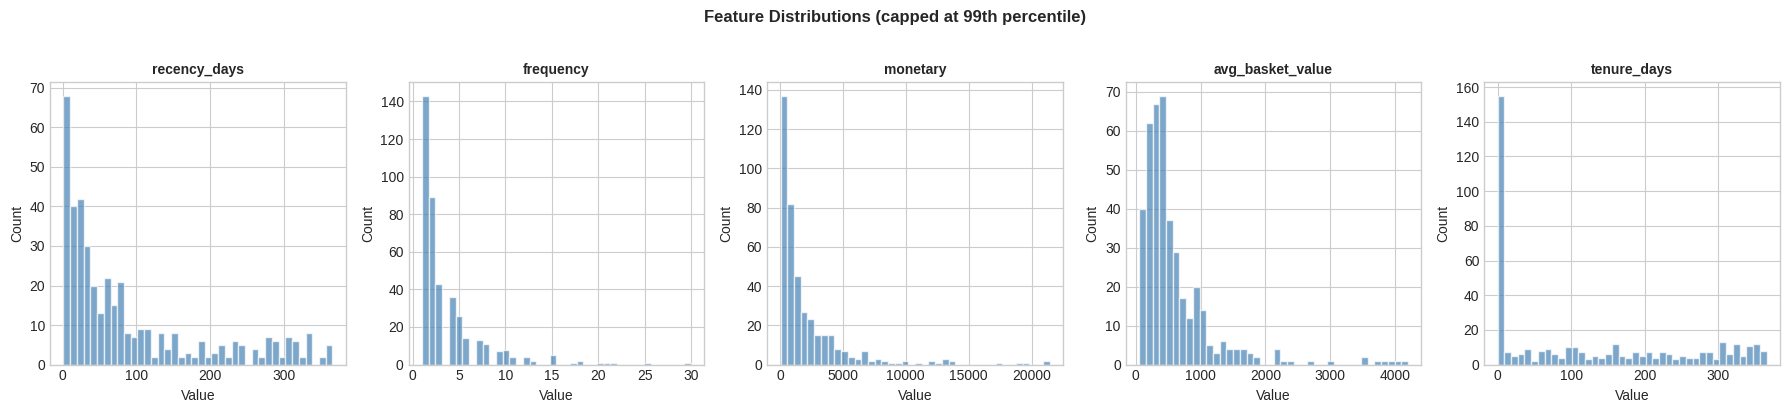


Observation: Most features are right-skewed — a small number of customers
have extremely high frequency/monetary values. StandardScaler handles the
centering, but log transformation may be beneficial for linear models.


In [ ]:
# ============================================================
# Feature Distribution Visualization
# Always visualize your features. Skewed distributions may need
# log transformation before feeding to linear models.
# ============================================================

features_to_plot = ['recency_days', 'frequency', 'monetary', 'avg_basket_value', 'tenure_days']

fig, axes = plt.subplots(1, len(features_to_plot), figsize=(18, 4))

for ax, feature in zip(axes, features_to_plot):
    data = customer_features[feature].dropna()
    # Cap at 99th percentile to avoid extreme outliers dominating the plot
    cap = data.quantile(0.99)
    ax.hist(data[data <= cap], bins=40, color='steelblue', alpha=0.7, edgecolor='white')
    ax.set_title(feature, fontweight='bold', fontsize=10)
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')

plt.suptitle('Feature Distributions (capped at 99th percentile)', fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\nObservation: Most features are right-skewed — a small number of customers")
print("have extremely high frequency/monetary values. StandardScaler handles the")
print("centering, but log transformation may be beneficial for linear models.")

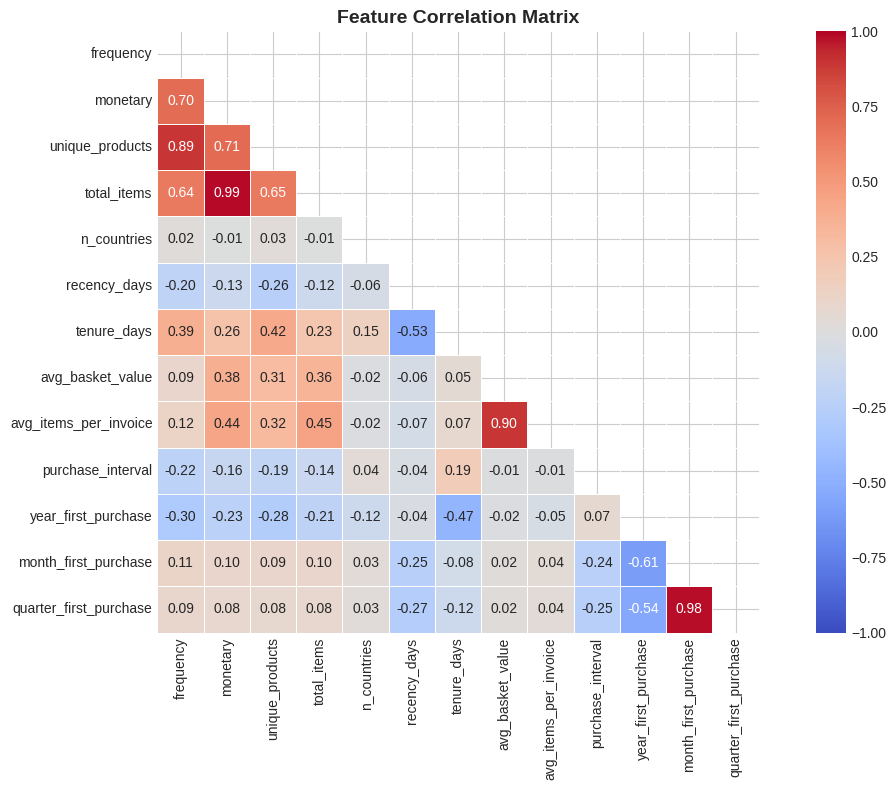

In [ ]:
# ============================================================
# Feature Correlation Heatmap
# Highly correlated features add redundancy without information.
# If frequency and monetary are 0.95 correlated, we may not need both.
# ============================================================

numeric_features = customer_features.select_dtypes(include=[np.number]).drop(columns=['CustomerID'], errors='ignore')

corr_matrix = numeric_features.corr()

fig, ax = plt.subplots(figsize=(12, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Upper triangle mask
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    ax=ax,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5
)
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
# Section 7 — Target Creation (Churn) — Leakage Prevention

## The Most Important Section in This Notebook

Temporal leakage is the silent killer of retail ML models. Models trained with leakage can achieve 99% accuracy in training and completely fail in production.

### What is Temporal Leakage?

Temporal leakage occurs when features used to train a model include information that would not have been available at prediction time in production.

### Why Churn Definition Requires Careful Thinking

**Churn Definition:** A customer is labeled as *churned* if they made no purchase in the 90 days following their last purchase (within the observation window).

**The Observation Window** is the period from which we derive features.

**The Prediction Window** is the future period we use to assign the churn label.

```
Timeline:
─────────────────────────────────────────────────────────────────
  |←─── Observation Window (features) ───→|←─ Prediction Window ─→|
  Start                               CUTOFF               CUTOFF+90
─────────────────────────────────────────────────────────────────
```

Features must only use data **before the cutoff**. Labels come from data **after the cutoff**.

### ❌ The Wrong Approach

```python
# WRONG: Using ALL data to compute recency, then labeling by recency
customer_features['churn'] = (customer_features['recency_days'] > 90).astype(int)
```

This leaks because `recency_days` is computed from `max(InvoiceDate)` — which includes future purchases relative to any training cutoff. The model learns that high recency = churn, which is trivially true by construction, not predictive of future behavior.

### ✅ The Correct Approach

Split the data at a cutoff date. Features come from the observation period. Labels come from whether the customer purchased after the cutoff.

In [ ]:
# ============================================================
# CELL: Temporal Churn Labeling — Correct Approach
#
# CUTOFF DATE: We choose a date 90 days before the end of the dataset.
# - Observation window: all data BEFORE cutoff → used to build features
# - Prediction window: data AFTER cutoff → used to assign churn label
#
# A customer who had ≥1 purchase before the cutoff but ZERO purchases
# after the cutoff is labeled churned=1.
# ============================================================

# Define the temporal split
CHURN_WINDOW_DAYS = 90  # Prediction window length
DATA_END_DATE = df['InvoiceDate'].max()
CUTOFF_DATE = DATA_END_DATE - timedelta(days=CHURN_WINDOW_DAYS)

print(f"Data range:    {df['InvoiceDate'].min().date()} → {DATA_END_DATE.date()}")
print(f"Cutoff date:   {CUTOFF_DATE.date()}")
print(f"Churn window:  {CHURN_WINDOW_DAYS} days")
print(f"\nObservation period: data before {CUTOFF_DATE.date()}")
print(f"Prediction period:  {CUTOFF_DATE.date()} → {DATA_END_DATE.date()}")

Data range:    2010-12-01 → 2011-12-09
Cutoff date:   2011-09-10
Churn window:  90 days

Observation period: data before 2011-09-10
Prediction period:  2011-09-10 → 2011-12-09


In [ ]:
# ============================================================
# Split data into observation and prediction periods
# CRITICAL: These must be separate. Never mix them.
# ============================================================

# Observation window: features are built from this data
df_obs = df[df['InvoiceDate'] < CUTOFF_DATE].copy()

# Prediction window: labels are derived from this data
df_pred = df[df['InvoiceDate'] >= CUTOFF_DATE].copy()

print(f"Observation rows: {len(df_obs):,}")
print(f"Prediction rows:  {len(df_pred):,}")

# Customers active before cutoff
customers_before = set(df_obs['CustomerID'].unique())

# Customers who purchased after cutoff (= not churned)
customers_after = set(df_pred['CustomerID'].unique())

print(f"\nCustomers active before cutoff: {len(customers_before):,}")
print(f"Customers active after cutoff:  {len(customers_after):,}")
print(f"Customers in BOTH periods:      {len(customers_before & customers_after):,}  ← not churned")
print(f"Customers in obs only:          {len(customers_before - customers_after):,}  ← churned")

Observation rows: 27,579
Prediction rows:  15,984

Customers active before cutoff: 335
Customers active after cutoff:  276
Customers in BOTH periods:      193  ← not churned
Customers in obs only:          142  ← churned


Churn rate: 42.4%
Churned:     142
Not churned: 193


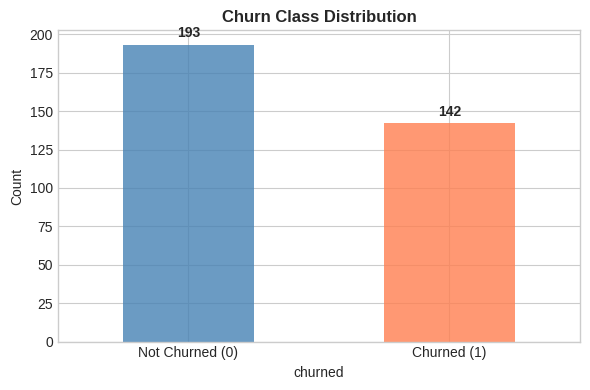

In [ ]:
# ============================================================
# Build features from OBSERVATION period only
# Use CUTOFF_DATE as the reference date for recency
# (not the full dataset's max date — that would be leakage!)
# ============================================================

customer_features_obs = build_customer_features(df_obs, CUTOFF_DATE)

# Create churn label
# churn=1 if customer did NOT purchase after the cutoff
customer_features_obs['churned'] = (
    ~customer_features_obs['CustomerID'].isin(customers_after)
).astype(int)

churn_rate = customer_features_obs['churned'].mean()
print(f"Churn rate: {churn_rate:.1%}")
print(f"Churned:     {customer_features_obs['churned'].sum():,}")
print(f"Not churned: {(customer_features_obs['churned']==0).sum():,}")

# Visualize class balance
fig, ax = plt.subplots(figsize=(6, 4))
customer_features_obs['churned'].value_counts().plot(
    kind='bar', ax=ax, color=['steelblue', 'coral'], alpha=0.8
)
ax.set_xticklabels(['Not Churned (0)', 'Churned (1)'], rotation=0)
ax.set_title('Churn Class Distribution', fontweight='bold')
ax.set_ylabel('Count')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width()/2, p.get_height() + 5),
                ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

---
# Section 8 — Train-Test Split (Time-Aware)

## Why Random Split is Dangerous for Temporal Data

A random 80/20 split will put some December 2011 customers in training and some in test. When you compute recency for a December 2011 customer, the model has seen customers from that same month in training. This is **temporal leakage**.

In production, you train on *historical* data and predict on *future* customers. The split must respect this directionality.

### Customer-Level Temporal Split

Since our features are already customer-level, we split by customer cohort — customers who first appeared before a split date go to training; customers who first appeared after go to testing. This mimics the real-world deployment scenario: the model is trained on known customers and evaluated on newer customers.

### Fit vs Transform

**Fit:** The process of learning parameters from data (e.g., computing mean and std for StandardScaler). This must only happen on training data.

**Transform:** Applying learned parameters to new data. This happens to both train and test.

If you fit your scaler on all data (train+test), you've leaked test statistics into training. The scaler has seen the test distribution — it's no longer a truly held-out set.

In [ ]:
# ============================================================
# CELL: Time-Aware Train-Test Split
#
# Strategy: Split customers by when they FIRST purchased.
# Customers with first_purchase before the TRAIN_CUTOFF → train
# Customers with first_purchase on/after TRAIN_CUTOFF → test
#
# We rebuild features here using the original df_obs so we can
# include first_purchase_date before aggregating.
# ============================================================

# Get first purchase date per customer from observation window
first_purchases = (
    df_obs.groupby('CustomerID')['InvoiceDate']
    .min()
    .reset_index()
    .rename(columns={'InvoiceDate': 'first_purchase_date'})
)

# Merge into customer features
modeling_df = customer_features_obs.merge(first_purchases, on='CustomerID', how='left')

# Set train-test split boundary
# We use the 80th percentile of first purchase dates as the split point.
# This gives ~80% to training chronologically.
TRAIN_CUTOFF = modeling_df['first_purchase_date'].quantile(0.80)
print(f"Train-test split date: {pd.Timestamp(TRAIN_CUTOFF).date()}")

train_mask = modeling_df['first_purchase_date'] <= TRAIN_CUTOFF
test_mask  = modeling_df['first_purchase_date'] >  TRAIN_CUTOFF

df_train = modeling_df[train_mask].copy()
df_test  = modeling_df[test_mask].copy()

print(f"\nTrain set: {len(df_train):,} customers | Churn rate: {df_train['churned'].mean():.1%}")
print(f"Test set:  {len(df_test):,} customers  | Churn rate: {df_test['churned'].mean():.1%}")

Train-test split date: 2011-06-17

Train set: 268 customers | Churn rate: 42.9%
Test set:  67 customers  | Churn rate: 40.3%


In [ ]:
# ============================================================
# Define feature columns and target
# ============================================================

# Numeric features — will be standardized
NUMERIC_FEATURES = [
    'recency_days',
    'frequency',
    'monetary',
    'avg_basket_value',
    'tenure_days',
    'unique_products',
    'total_items',
    'avg_items_per_invoice',
    'year_first_purchase',
    'month_first_purchase',
]

# Categorical features — will be one-hot encoded
CATEGORICAL_FEATURES = [
    'dominant_country',
]

TARGET = 'churned'
ID_COL = 'CustomerID'

# Prepare X and y
X_train = df_train[NUMERIC_FEATURES + CATEGORICAL_FEATURES].copy()
y_train = df_train[TARGET]

X_test  = df_test[NUMERIC_FEATURES + CATEGORICAL_FEATURES].copy()
y_test  = df_test[TARGET]

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"\nNumeric features ({len(NUMERIC_FEATURES)}): {NUMERIC_FEATURES}")
print(f"\nCategorical features ({len(CATEGORICAL_FEATURES)}): {CATEGORICAL_FEATURES}")

X_train shape: (268, 11)
X_test shape:  (67, 11)

Numeric features (10): ['recency_days', 'frequency', 'monetary', 'avg_basket_value', 'tenure_days', 'unique_products', 'total_items', 'avg_items_per_invoice', 'year_first_purchase', 'month_first_purchase']

Categorical features (1): ['dominant_country']


In [ ]:
# ============================================================
# Handle purchase_interval NaN for single-purchase customers
# Impute with median — median is more robust to outliers than mean
# We use training median only (computed after the split)
# ============================================================

# Fill NaN in numeric features with training median
# This is done manually here for transparency; in the sklearn Pipeline
# below we will use SimpleImputer which handles this automatically
# and correctly fits on train only.
for col in NUMERIC_FEATURES:
    if X_train[col].isnull().any():
        median_val = X_train[col].median()
        X_train[col] = X_train[col].fillna(median_val)
        X_test[col]  = X_test[col].fillna(median_val)  # Use TRAIN median on test
        print(f"Imputed {col} with training median: {median_val:.2f}")

# Optional Section
### You can revisit this after learning Classification algorithms

---
# Section 9 — Machine Learning Pipeline

## Why sklearn Pipeline?

An sklearn `Pipeline` bundles preprocessing and modeling into a single object. This has three major production advantages:

1. **Leakage prevention:** The pipeline ensures that preprocessing (scaling, encoding) is always fit on training data and only applied (transformed) to test data — even inside cross-validation.

2. **Deployment simplicity:** You save one object, load one object. The same pipeline that trained also predicts. No need to re-run preprocessing steps separately before calling `.predict()`.

3. **Experiment consistency:** Every experiment uses the same preprocessing. No risk of "accidentally" using a different scaler in one experiment.

## Architecture

```
Pipeline
│
├── ColumnTransformer (preprocessing)
│   ├── numeric_pipeline
│   │   └── StandardScaler
│   └── categorical_pipeline
│       └── OneHotEncoder
│
└── LogisticRegression (classifier)
```

In [ ]:
# ============================================================
# CELL: Build the sklearn Pipeline
# ============================================================
from sklearn.impute import SimpleImputer

# --- Numeric transformer ---
# SimpleImputer: fills remaining NaNs (fit on train, transform both)
# StandardScaler: zero mean, unit variance (fit on train, transform both)
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),  # Robust to outliers
    ('scaler',  StandardScaler()),
])

# --- Categorical transformer ---
# handle_unknown='ignore': if test set has a country not seen in training,
# it gets all-zeros encoding instead of raising an error.
# sparse_output=False: return dense array for compatibility
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

# --- ColumnTransformer: routes columns to the right transformer ---
preprocessor = ColumnTransformer(
    transformers=[
        ('numeric',      numeric_transformer,      NUMERIC_FEATURES),
        ('categorical',  categorical_transformer,  CATEGORICAL_FEATURES),
    ],
    remainder='drop'  # Drop any columns not explicitly listed
)

# --- Full Pipeline: preprocessing + model ---
# class_weight='balanced': adjusts for class imbalance automatically
# max_iter=1000: sufficient iterations for convergence on this dataset
churn_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier',   LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=RANDOM_SEED,
        C=1.0,  # Regularization strength — 1.0 is the default; tune via CV
    )),
])

print("Pipeline architecture:")
print(churn_pipeline)

Pipeline architecture:
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['recency_days', 'frequency',
                                                   'monetary',
                                                   'avg_basket_value',
                                                   'tenure_days',
                                                   'unique_products',
                                                   'total_items',
                                                   'avg_items_per_invoice',
                                              

In [ ]:
# ============================================================
# CELL: Train the Pipeline
# .fit() on training data:
#   - Fits imputers, scaler, encoder on X_train
#   - Fits LogisticRegression on transformed X_train
# ============================================================

logger.info("Training pipeline...")
churn_pipeline.fit(X_train, y_train)
logger.info("Training complete.")

In [ ]:
# ============================================================
# CELL: Cross-Validation on Training Set
# Cross-validation gives a more reliable performance estimate
# than a single train-test split.
# We use ROC-AUC — appropriate for imbalanced binary classification.
# ============================================================

cv_scores = cross_val_score(
    churn_pipeline,
    X_train, y_train,
    cv=5,                  # 5-fold CV
    scoring='roc_auc',
    n_jobs=-1              # Use all CPU cores
)

print("Cross-Validation ROC-AUC (5-fold):")
print(f"  Scores: {cv_scores.round(4)}")
print(f"  Mean:   {cv_scores.mean():.4f}")
print(f"  Std:    {cv_scores.std():.4f}")
print(f"\nA high std means the model is sensitive to which fold is held out.")
print(f"In time-series data, this often indicates temporal non-stationarity.")

Cross-Validation ROC-AUC (5-fold):
  Scores: [0.7532 0.7714 0.7097 0.7812 0.7464]
  Mean:   0.7524
  Std:    0.0247

A high std means the model is sensitive to which fold is held out.
In time-series data, this often indicates temporal non-stationarity.


In [ ]:
# ============================================================
# CELL: Evaluate on Test Set
# The test set is a true held-out set — the model has never
# seen these customers during training.
# ============================================================

y_pred  = churn_pipeline.predict(X_test)
y_proba = churn_pipeline.predict_proba(X_test)[:, 1]

print("=" * 50)
print("TEST SET EVALUATION")
print("=" * 50)
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Not Churned', 'Churned']))

TEST SET EVALUATION
ROC-AUC: 0.5528

Classification Report:
              precision    recall  f1-score   support

 Not Churned       0.69      0.28      0.39        40
     Churned       0.43      0.81      0.56        27

    accuracy                           0.49        67
   macro avg       0.56      0.54      0.48        67
weighted avg       0.58      0.49      0.46        67



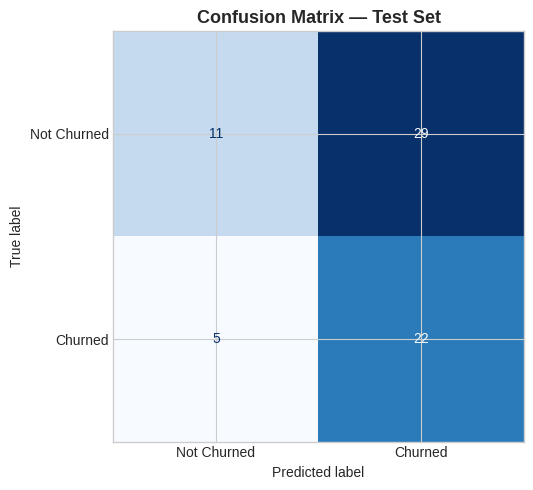

True Negatives  (correct: not churned): 11
False Positives (wrong alarm):           29
False Negatives (missed churn):          5
True Positives  (correct: churned):      22


In [ ]:
# ============================================================
# CELL: Confusion Matrix
# In churn prediction, business priorities matter:
# - False Negative (missed churn): Customer leaves without intervention
# - False Positive (wrong alarm): Wasted retention spend on loyal customer
# The optimal threshold depends on the relative cost of each error.
# ============================================================

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Not Churned', 'Churned']
)
disp.plot(ax=ax, cmap='Blues', values_format='d', colorbar=False)
ax.set_title('Confusion Matrix — Test Set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives  (correct: not churned): {tn}")
print(f"False Positives (wrong alarm):           {fp}")
print(f"False Negatives (missed churn):          {fn}")
print(f"True Positives  (correct: churned):      {tp}")

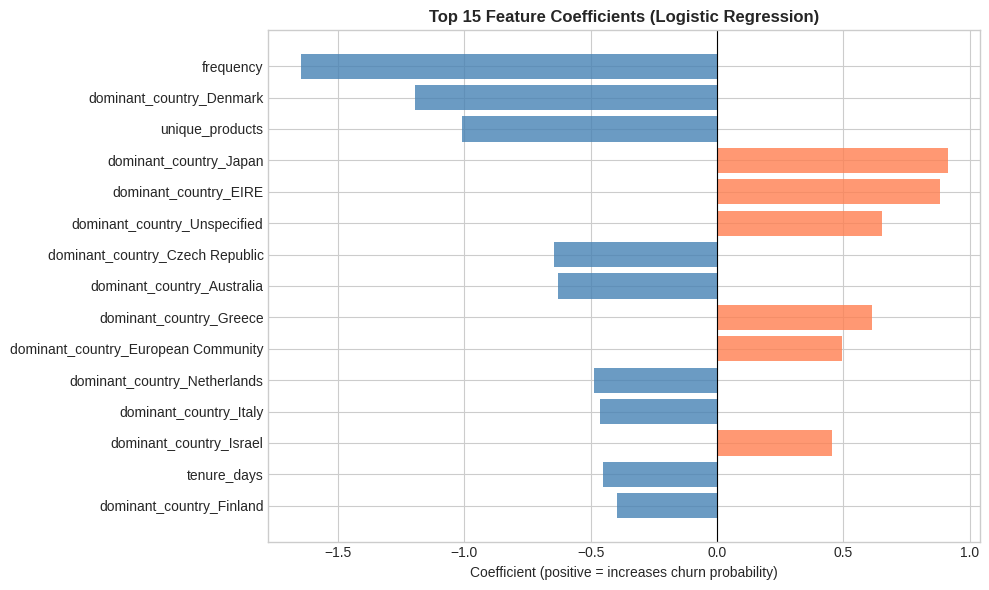

In [ ]:
# ============================================================
# CELL: Feature Importance (Logistic Regression Coefficients)
# For linear models, the coefficient magnitude indicates
# feature importance (after scaling).
# ============================================================

# Get feature names after transformation
num_feature_names = NUMERIC_FEATURES
cat_feature_names = (
    churn_pipeline.named_steps['preprocessor']
    .named_transformers_['categorical']
    .named_steps['encoder']
    .get_feature_names_out(CATEGORICAL_FEATURES)
    .tolist()
)
all_feature_names = num_feature_names + cat_feature_names

# Extract coefficients
coefficients = churn_pipeline.named_steps['classifier'].coef_[0]

importance_df = pd.DataFrame({
    'feature': all_feature_names,
    'coefficient': coefficients,
    'abs_coefficient': np.abs(coefficients)
}).sort_values('abs_coefficient', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['coral' if c > 0 else 'steelblue' for c in importance_df['coefficient']]
ax.barh(importance_df['feature'], importance_df['coefficient'], color=colors, alpha=0.8)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_title('Top 15 Feature Coefficients (Logistic Regression)', fontweight='bold')
ax.set_xlabel('Coefficient (positive = increases churn probability)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

---
# Section 10 — Model Persistence

## Why Save the Full Pipeline?

In production, your API endpoint receives raw features and must return a churn probability. If you save only the model weights, the API must also run the preprocessing steps — which must be implemented identically to training.

By saving the full `Pipeline` object, you save:
- The imputer with its training medians
- The scaler with its training means and standard deviations
- The one-hot encoder with its training categories
- The logistic regression with its coefficients

Loading the pipeline gives you one object that can `.predict()` directly from raw feature values — no preprocessing code needed separately.

## joblib vs pickle

Both serialize Python objects. `joblib` is preferred for sklearn objects because:
- It uses memory-mapped numpy arrays (faster loading for large models)
- It handles numpy arrays more efficiently than standard pickle
- It's the sklearn-recommended serialization method

In [ ]:
# ============================================================
# CELL: Save Full Pipeline
# Include a version identifier and metadata file alongside
# the model artifact — critical for model governance.
# ============================================================
import json

MODEL_DIR = Path('models')
MODEL_DIR.mkdir(exist_ok=True)

MODEL_VERSION = 'v1.0.0'
MODEL_PATH = MODEL_DIR / f'churn_pipeline_{MODEL_VERSION}.joblib'

# Save the pipeline
joblib.dump(churn_pipeline, MODEL_PATH)
print(f"Pipeline saved to: {MODEL_PATH}")
print(f"File size: {MODEL_PATH.stat().st_size / 1024:.1f} KB")

# Save metadata alongside the model
metadata = {
    'model_version': MODEL_VERSION,
    'training_date': datetime.now().isoformat(),
    'cutoff_date': str(CUTOFF_DATE.date()),
    'churn_window_days': CHURN_WINDOW_DAYS,
    'numeric_features': NUMERIC_FEATURES,
    'categorical_features': CATEGORICAL_FEATURES,
    'target': TARGET,
    'train_size': len(X_train),
    'test_size': len(X_test),
    'test_roc_auc': round(roc_auc_score(y_test, y_proba), 4),
    'random_seed': RANDOM_SEED,
    'model_type': 'LogisticRegression',
}

META_PATH = MODEL_DIR / f'churn_pipeline_{MODEL_VERSION}_metadata.json'
with open(META_PATH, 'w') as f:
    json.dump(metadata, f, indent=2)

print(f"\nMetadata saved to: {META_PATH}")
print(json.dumps(metadata, indent=2))

Pipeline saved to: models/churn_pipeline_v1.0.0.joblib
File size: 5.5 KB

Metadata saved to: models/churn_pipeline_v1.0.0_metadata.json
{
  "model_version": "v1.0.0",
  "training_date": "2026-09-21T02:01:34.651819",
  "cutoff_date": "2011-09-10",
  "churn_window_days": 90,
  "numeric_features": [
    "recency_days",
    "frequency",
    "monetary",
    "avg_basket_value",
    "tenure_days",
    "unique_products",
    "total_items",
    "avg_items_per_invoice",
    "year_first_purchase",
    "month_first_purchase"
  ],
  "categorical_features": [
    "dominant_country"
  ],
  "target": "churned",
  "train_size": 268,
  "test_size": 67,
  "test_roc_auc": 0.5528,
  "random_seed": 42,
  "model_type": "LogisticRegression"
}


In [ ]:
# ============================================================
# CELL: Verify Round-Trip Load & Predict
# Always verify that the saved model loads correctly and
# produces identical predictions. This catches serialization bugs.
# ============================================================

loaded_pipeline = joblib.load(MODEL_PATH)

# Predictions must be identical
y_pred_loaded = loaded_pipeline.predict(X_test)
y_proba_loaded = loaded_pipeline.predict_proba(X_test)[:, 1]

assert np.array_equal(y_pred, y_pred_loaded), "Predictions differ after load!"
assert np.allclose(y_proba, y_proba_loaded), "Probabilities differ after load!"

print("✅ Round-trip verification passed: loaded model produces identical predictions.")
print(f"\nTo use in production:")
print("  pipeline = joblib.load('models/churn_pipeline_v1.0.0.joblib')")
print("  proba    = pipeline.predict_proba(X_new)[:, 1]")
print("  (X_new must contain the same feature columns as X_train)")

✅ Round-trip verification passed: loaded model produces identical predictions.

To use in production:
  pipeline = joblib.load('models/churn_pipeline_v1.0.0.joblib')
  proba    = pipeline.predict_proba(X_new)[:, 1]
  (X_new must contain the same feature columns as X_train)


---
# Section 11 — Production Best Practices

Moving from a notebook to production requires addressing concerns that don't appear in experimental code. This section discusses the mindset shifts required.

## Logging

In production, `print()` statements are invisible. Use structured logging (`logging` module or `structlog`) so every pipeline run leaves a traceable audit trail. Log:
- Input data shape and date range
- Row counts at each cleaning step (data volume audit)
- Feature statistics (mean, std) — drift detection
- Prediction distribution (model behavior audit)
- Errors with full stack traces

```python
# Good logging pattern
logger.info("Pipeline started", extra={'job_id': job_id, 'input_rows': len(df)})
logger.warning("High missing rate", extra={'column': 'CustomerID', 'missing_pct': 0.25})
logger.error("Pipeline failed", exc_info=True, extra={'step': 'parse_invoice_date'})
```

## Versioning

Every artifact in production must be versioned:
- **Data version:** The exact dataset (hash or timestamp) used to train
- **Code version:** Git commit SHA of the training code
- **Model version:** Semantic version with accompanying metadata JSON
- **Feature schema version:** A contract for what columns the model expects

Without versioning, you cannot:
- Reproduce a past model's behavior
- Safely roll back to a previous model
- Audit which model made which prediction

## Feature Documentation

Every feature in production must have a documented:
- **Definition** (exact formula)
- **Source table(s)**
- **Business meaning**
- **Expected range and distribution**
- **Null handling**

Without this, the next engineer inheriting the model cannot validate whether new data generates features correctly.

## Determinism

Set all random seeds explicitly (`RANDOM_SEED = 42`). Fix library versions in requirements.txt. Log the random seed in model metadata. Use the same Python version in dev and production. Determinism means:
- Re-running with the same data produces the same model
- Debugging is possible (you can reproduce the exact failure)
- A/B testing is valid (models differ only by what you intended)

## Monitoring

After deployment, models degrade silently. Monitor:
- **Data drift:** Are input feature distributions shifting? (PSI, KL divergence)
- **Concept drift:** Is the relationship between features and target changing?
- **Prediction drift:** Is the model's output distribution shifting?
- **Business metrics:** Are customers targeted by retention campaigns actually churning less?

Set alerts when any monitored metric crosses a threshold. Retrain on a schedule or trigger-based.

In [ ]:
# ============================================================
# CELL: Prediction Distribution Monitoring (Baseline)
# Capture the prediction distribution at training time.
# In production, compare live predictions against this baseline.
# A large shift signals model or data drift.
# ============================================================

prediction_baseline = {
    'train_churn_rate': float(y_train.mean()),
    'test_churn_rate':  float(y_test.mean()),
    'mean_predicted_proba_train': float(churn_pipeline.predict_proba(X_train)[:, 1].mean()),
    'mean_predicted_proba_test':  float(y_proba.mean()),
    'p25_proba_test': float(np.percentile(y_proba, 25)),
    'p75_proba_test': float(np.percentile(y_proba, 75)),
    'roc_auc_test': float(roc_auc_score(y_test, y_proba)),
}

BASELINE_PATH = MODEL_DIR / f'prediction_baseline_{MODEL_VERSION}.json'
with open(BASELINE_PATH, 'w') as f:
    json.dump(prediction_baseline, f, indent=2)

print("Prediction Baseline (saved for monitoring):")
print(json.dumps(prediction_baseline, indent=2))
print(f"\nSaved to: {BASELINE_PATH}")

Prediction Baseline (saved for monitoring):
{
  "train_churn_rate": 0.4291044776119403,
  "test_churn_rate": 0.40298507462686567,
  "mean_predicted_proba_train": 0.4740612647585625,
  "mean_predicted_proba_test": 0.599035317386616,
  "p25_proba_test": 0.5267094366086921,
  "p75_proba_test": 0.6872778954782022,
  "roc_auc_test": 0.5527777777777778
}

Saved to: models/prediction_baseline_v1.0.0.json


---
# Section 12 — Scaling Considerations

## When Does Pandas Fail?

Pandas is excellent for datasets up to ~5GB in RAM. Beyond that:
- Operations create copies (2–3× memory amplification during transformations)
- GroupBy on string columns is slow (no parallel execution)
- Loading a 20GB CSV simply may not fit in RAM

## Chunk-Based CSV Reading

For large files that don't fit in RAM, pandas can process the CSV in chunks. Each chunk is processed separately and results are aggregated.

In [ ]:
# ============================================================
# CELL: Chunk-Based Processing Pattern
# This pattern works when you need to aggregate statistics
# across a file too large to load into RAM at once.
# ============================================================

def compute_revenue_from_chunks(filepath: str, chunksize: int = 50_000) -> pd.DataFrame:
    """
    Compute total revenue per customer from a large CSV
    by processing it in memory-efficient chunks.

    This pattern works for any aggregation where:
    - The aggregation is associative (sum, count, max, min)
    - You can accumulate partial results across chunks

    Args:
        filepath: Path to the CSV file.
        chunksize: Number of rows per chunk (tune based on available RAM).

    Returns:
        Customer-level revenue DataFrame.
    """
    partial_results = []

    for i, chunk in enumerate(pd.read_csv(filepath, chunksize=chunksize, encoding='latin-1')):
        # Apply minimal cleaning per chunk
        chunk = chunk.dropna(subset=['CustomerID'])
        chunk = chunk[chunk['Quantity'] > 0]
        chunk = chunk[chunk['UnitPrice'] > 0]
        chunk['Revenue'] = chunk['Quantity'] * chunk['UnitPrice']

        # Aggregate within this chunk
        partial = chunk.groupby('CustomerID')['Revenue'].sum().reset_index()
        partial_results.append(partial)

        if i % 10 == 0:
            logger.info(f"Processed chunk {i} | Rows so far: ~{(i+1)*chunksize:,}")

    # Combine and re-aggregate across chunks
    # (a customer may appear in multiple chunks)
    combined = pd.concat(partial_results, ignore_index=True)
    final = combined.groupby('CustomerID')['Revenue'].sum().reset_index()

    return final


# NOTE: This is a demonstration pattern — it would work on retail_data.csv
# but is most useful for 10GB+ files where pd.read_csv fails with OOM.
# Uncomment to run:
# revenue_chunked = compute_revenue_from_chunks('retail_data.csv', chunksize=50_000)

print("Chunk-based processing pattern defined.")
print("Key insight: aggregate within chunks, then re-aggregate combined results.")

Chunk-based processing pattern defined.
Key insight: aggregate within chunks, then re-aggregate combined results.


## Dask — Scaling Beyond RAM

Dask provides a pandas-compatible API that runs operations lazily across multiple cores or a cluster. The syntax is nearly identical to pandas:

```python
import dask.dataframe as dd

# Read entire CSV — lazily (no data loaded yet)
ddf = dd.read_csv('retail_data_large.csv', encoding='latin-1')

# Operations are identical to pandas
revenue = (
    ddf[ddf['Quantity'] > 0]
    .assign(Revenue=lambda d: d['Quantity'] * d['UnitPrice'])
    .groupby('CustomerID')['Revenue']
    .sum()
)

# Trigger computation — this is where Dask actually reads and processes
result = revenue.compute()
```

**When to use Dask:**
- Data doesn't fit in RAM (10GB–100GB)
- You have multiple cores and want to parallelize
- Operations are pandas-compatible (groupby, merge, apply)

## Polars — Modern High-Performance DataFrames

Polars is a newer library written in Rust. It offers:
- Lazy evaluation (like Dask, but in-process)
- Apache Arrow columnar memory format
- Multi-threaded operations by default
- Typically 5–20× faster than pandas on equivalent operations

```python
import polars as pl

df = pl.read_csv('retail_data.csv', encoding='latin-1')

revenue = (
    df
    .filter(pl.col('Quantity') > 0)
    .with_columns((pl.col('Quantity') * pl.col('UnitPrice')).alias('Revenue'))
    .group_by('CustomerID')
    .agg(pl.col('Revenue').sum())
)
```

**When to use Polars:**
- Data fits in RAM but speed matters
- You're doing heavy ETL/feature engineering
- You can tolerate a different API from pandas

## Decision Framework

| Data Size | Recommendation |
|-----------|----------------|
| < 1GB | Pandas — simple, familiar |
| 1GB – 5GB | Pandas + memory optimization (category dtype, float32) |
| 5GB – 50GB | Polars (in-memory speed) or Dask (larger-than-RAM) |
| 50GB+ | Spark or cloud-native (BigQuery, Snowflake, Databricks) |

---
# Section 13 — Final Summary

## What We Built

A complete, production-oriented ML pipeline for retail customer churn prediction:

```
retail_data.csv (transaction-level)
     ↓
run_pipeline()         → Deterministic cleaning (5 modular steps)
     ↓
build_customer_features() → Customer-level RFM + behavioral features
     ↓
Temporal target creation  → Churn label from prediction window
     ↓
Time-aware train-test split → No temporal leakage
     ↓
sklearn Pipeline (ColumnTransformer + LogisticRegression)
     ↓
Evaluation (ROC-AUC, confusion matrix, coefficients)
     ↓
joblib persistence → Versioned model + metadata + baseline
```

## Key Takeaways

**1. Pipelines prevent chaos.** A modular pipeline is testable, readable, and maintainable. A 200-line notebook cell is none of those things.

**2. Temporal leakage is the #1 cause of production model failure in e-commerce.** Always define a clear observation window and prediction window before building features or labels.

**3. Granularity mismatch is a fundamental data engineering problem.** Raw data arrives at transaction level. Models predict at customer level. The aggregation is a modeling decision — document every choice.

**4. Save the full pipeline, not just the model.** A model weight file without its preprocessing context is useless in production.

**5. Memory optimization is not optional at scale.** A `category` dtype conversion can reduce a column's memory footprint by 10×. At 10M rows, this is the difference between running and crashing.

**6. Feature engineering is where the domain expertise lives.** The RFM framework isn't magic — it encodes decades of direct marketing intuition about customer behavior. Understanding *why* recency predicts churn is more valuable than knowing how to compute it.

## Production Mindset Checklist

Before declaring any ML project "production ready," verify:

- [ ] All cleaning steps are in pure, named functions
- [ ] Reference dates are fixed, not `datetime.now()`
- [ ] No data after the observation cutoff was used to build features
- [ ] Train-test split is temporal, not random
- [ ] Scaler/encoder was fit only on training data
- [ ] Model and metadata are versioned and saved together
- [ ] Prediction distribution baseline is captured
- [ ] Random seeds are set and logged
- [ ] All features are documented (definition, source, expected range)
- [ ] Round-trip load verification passes

---

*This notebook was built to teach professional data engineering and ML practices. The goal is not just to predict churn — it is to predict it in a way that can be deployed, monitored, maintained, and improved by a team over time.*